In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [1]:
import os


import numpy as np
from dask.distributed import LocalCluster,Client

from libraries import AEM_preproc, ProbEM,HIpy,HIES
from libraries.SigNULL_Det import Sounding
import matplotlib.pyplot as plt

import warnings
from bokeh.util.warnings import BokehUserWarning
import matplotlib.colors as mcolors
import pandas as pd
# Silence the visualization warnings
warnings.simplefilter("ignore", BokehUserWarning)

j:\GWater\schoningg\REPOS\ProbEM\libraries\SigNULL_Det.py:7: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  from SimPEG.data import Data


In [2]:
DFILE = r"J:\GWater\schoningg\RTO\data\All_AVG_export.gz.parquet"
#DFILE=r"J:\GWater\schoningg\REPOS\ProbEM\data\Dalby_EM_MGA55.XYZ"
GEXFILE = r"J:\GWater\schoningg\RTO\data\20230616_10098_306HP_LM_MergeGates_HM_splinegates_final_Z_V3.gex"
Survey = AEM_preproc.Survey()
Survey.proc_gex(GEXFILE)

Survey.add_data(DFILE)

lineno = 105601
times = Survey.time_list(line=lineno)
time = times[109]



In [ ]:
# --- Setup Parameters ---
cluster = LocalCluster(n_workers=64)
client = Client(cluster)

Chi-squared Misfit: 0.41
Calibrated Mean: 0.0136 S/m
Winning Corr Length: 3.08493243280612
Function Evaluations: 852

--- Solver Brain Dump ---
Iter 1  | [L2] | Beta: 7.51e+00 | Chi2: 3.97 | Underfit -> Lower Beta
Iter 2  | [L2] | Beta: 3.75e+00 | Chi2: 0.95 | Underfit -> Lower Beta
Iter 3  | [L1] | Beta: 1.50e+01 | Chi2: 0.85 | Stalled -> Reset & Kick
Iter 4  | [L1] | Beta: 7.51e+00 | Chi2: 0.70 | Underfit -> Lower Beta
Iter 5  | [L1] | Beta: 3.75e+00 | Chi2: 0.58 | Underfit -> Lower Beta
Iter 6  | [L1] | Beta: 1.50e+01 | Chi2: 0.54 | Stalled -> Reset & Kick
Iter 7  | [L1] | Beta: 7.51e+00 | Chi2: 0.71 | Underfit -> Lower Beta
Iter 8  | [L1] | Beta: 3.75e+00 | Chi2: 0.58 | Underfit -> Lower Beta
Iter 9  | [L1] | Beta: 1.50e+01 | Chi2: 0.52 | Stalled -> Reset & Kick
Iter 10 | [L1] | Beta: 7.51e+00 | Chi2: 0.71 | Underfit -> Lower Beta
Iter 11 | [L1] | Beta: 3.75e+00 | Chi2: 0.58 | Underfit -> Lower Beta
Iter 12 | [L1] | Beta: 1.88e+00 | Chi2: 0.45 | Underfit -> Lower Beta
Iter 13 | [L1

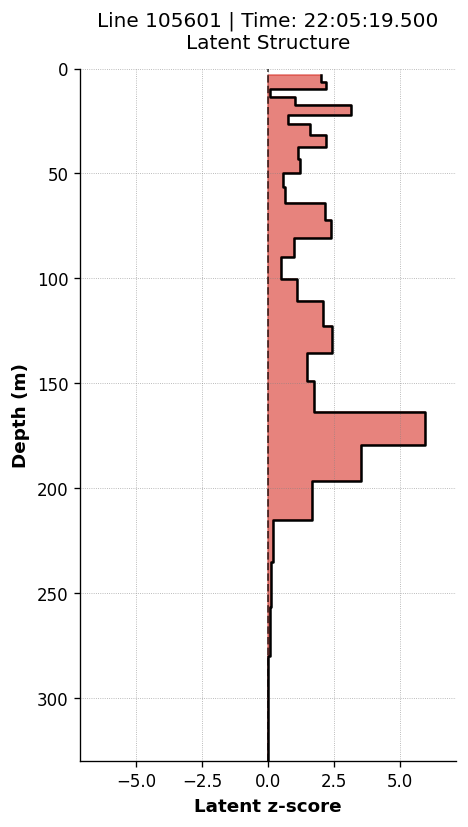

In [ ]:
inv_thickness = np.logspace(np.log10(3), np.log10(25.0), 29)
# 1. Create the sounding object
time='22:05:19.500'
snd = Sounding(Survey, lineno, time, inv_thickness)

snd.get_deterministic(client, bg_mean=np.log(0.01),corr_len=3)

# Extract your results directly:
recovered_conductivity = snd.Det.sigma
latent_z_scores = snd.Det.z
data_misfit = snd.Det.chival

print(f"Chi-squared Misfit: {snd.Det.chival:.2f}")
print(f"Calibrated Mean: {np.exp(snd.Det.mu):.4f} S/m")
print(f"Winning Corr Length: {snd.Det.corr_len}")
print(f"Function Evaluations: {snd.Det.nfev}")
print("\n--- Solver Brain Dump ---")
for log in snd.Det.logs:
    print(log)

import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with a slightly wider canvas and higher resolution
fig, ax = plt.subplots(figsize=(4, 7), dpi=120)

# 1. Plot the step function (using 'post' so the value extends down through the layer)
ax.step(latent_z_scores, snd.Depths, where='pre', color='black', linewidth=1.5)

# 2. Add a clear vertical reference line at exactly 0 (your background mean)
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)

# 3. Fill the anomalies to highlight structural changes
# Red for positive z-scores (more conductive than background)
ax.fill_betweenx(snd.Depths, 0, latent_z_scores, step='post', 
                 where=(latent_z_scores > 0), color='#d73027', alpha=0.6)
# Blue for negative z-scores (more resistive than background)
ax.fill_betweenx(snd.Depths, 0, latent_z_scores, step='post', 
                 where=(latent_z_scores <= 0), color='#4575b4', alpha=0.6)

# 4. Axis limits and inversion
ax.invert_yaxis()
ax.set_ylim(snd.Depths[-1], 0)  # Lock the bottom of the plot to your max depth

# Force the x-axis to be perfectly symmetric around 0 
x_max = max(1.5, np.max(np.abs(latent_z_scores)) * 1.2)
ax.set_xlim(-x_max, x_max)

# 5. Professional labeling and grid styling
ax.set_xlabel('Latent z-score', fontsize=11, fontweight='bold')
ax.set_ylabel('Depth (m)', fontsize=11, fontweight='bold')
ax.set_title(f'Line {lineno} | Time: {time}\nLatent Structure', fontsize=12, pad=12)

ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='gray', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
from dask.distributed import as_completed
from libraries.SigNULL_Det import solve_deterministic_worker
import numpy as np

# 1. Setup your line
lineno = 105601
times = Survey.time_list(line=lineno)
total_soundings = len(times)

# We will store the Futures here, mapping them to their specific fiducial time
futures_dict = {}
inv_thickness = np.logspace(np.log10(1), np.log10(23.0), 29)

print(f"Extracting payloads and submitting {total_soundings} soundings to the cluster...")

# 2. FIRE AND FORGET LOOP
for time in times:
    try:
        # Attempt to build the sounding
        snd = Sounding(Survey, lineno, time, inv_thickness)
        
        # Extract the lightweight payload directly
        src0 = snd.srv.source_list[0]
        src1 = snd.srv.source_list[1]
        
        payload = {
            'thicknesses': snd.inv_thickness,
            'rx_loc': src0.receiver_list[0].locations[0],
            'tx_shape': src0.location,
            'tx_area': snd.tx_area,
            'lm_times': src0.receiver_list[0].times,
            'hm_times': src1.receiver_list[0].times,
            'lm_wave_time': getattr(src0.waveform, 'times', None),
            'lm_wave_form': getattr(src0.waveform, 'currents', None),
            'hm_wave_time': getattr(src1.waveform, 'times', None),
            'hm_wave_form': getattr(src1.waveform, 'currents', None)
        }
        
        # Submit to cluster INSTANTLY using the Simultaneous Worker
        fut = client.submit(
            solve_deterministic_worker,snd.dobs, snd.uncertainties, payload, 
            np.log(0.01), corr_len=10.0, target_chi2=0.5, transform_type='svd',use_IRLS=True) 
    
        # Map the future ticket to the specific fiducial time
        futures_dict[fut] = time 
        
    except KeyError:
        print(f"\nSkipping time {time}: Not found in HM or LM data index.")
        continue
    
# 3. REAL-TIME PROGRESS TRACKER
completed_count = 0
line_results = {}

print("\n--- Inversion Started ---")

# Passing the dictionary directly is the safest way to iterate Dask futures
for fut in as_completed(futures_dict):
    completed_count += 1
    time_fid = futures_dict[fut]
    
    # Grab the result from the worker's memory
    res = fut.result() 
    line_results[time_fid] = res
    
    waiting_count = total_soundings - completed_count
    
    # Print the progress on a single dynamically updating line
    print(f"Progress: {completed_count}/{total_soundings} done | {waiting_count} waiting | Just finished fid: {time_fid}   ", end='\r')

print("\n\n--- Line 105601 Complete! ---")

Extracting payloads and submitting 1148 soundings to the cluster...

Skipping time 22:10:42.500: Not found in HM or LM data index.

Skipping time 22:10:43.500: Not found in HM or LM data index.

Skipping time 22:10:44.500: Not found in HM or LM data index.

Skipping time 22:10:45.500: Not found in HM or LM data index.

Skipping time 22:10:46.500: Not found in HM or LM data index.

Skipping time 22:19:19.500: Not found in HM or LM data index.

Skipping time 22:19:20.500: Not found in HM or LM data index.

Skipping time 22:19:21.500: Not found in HM or LM data index.

Skipping time 22:19:22.500: Not found in HM or LM data index.

Skipping time 22:19:23.500: Not found in HM or LM data index.

Skipping time 22:19:24.500: Not found in HM or LM data index.

--- Inversion Started ---
Progress: 1137/1148 done | 11 waiting | Just finished fid: 22:19:15.500    

--- Line 105601 Complete! ---


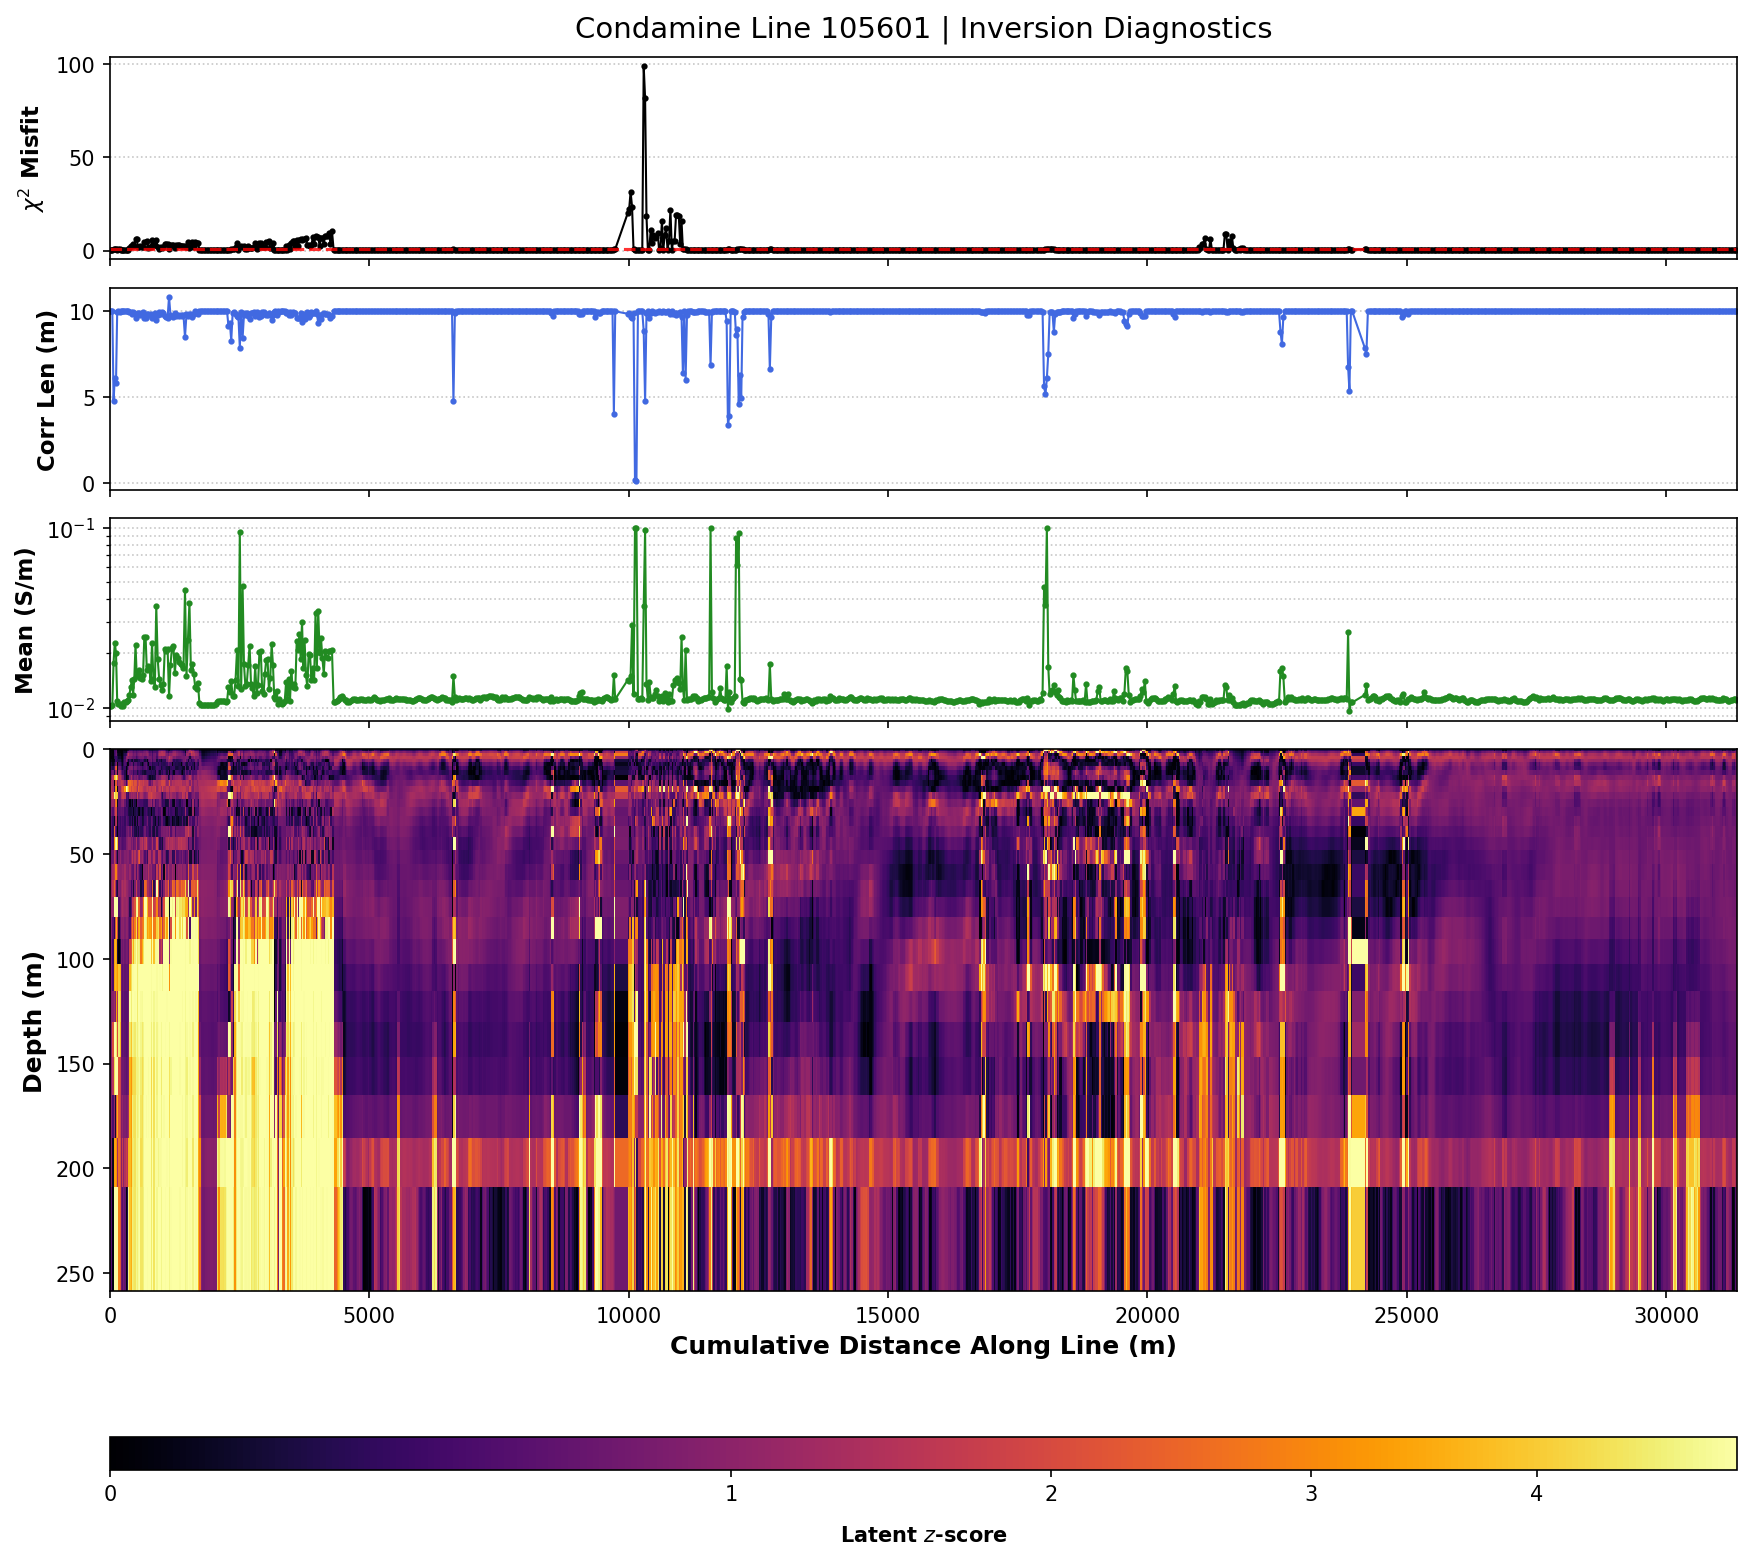

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Filter and sort completed soundings chronologically
valid_times = [t for t, res in line_results.items() if res.get('success', False)]
valid_times.sort()

if len(valid_times) == 0:
    print("No successful soundings completed yet. Wait a bit longer!")
else:
    # 2. Extract Data
    z_matrix = []
    x_coords = []
    y_coords = []
    chi2_vals = []
    mu_vals = []
    corr_vals = []
    
    for t in valid_times:
        res = line_results[t]
        z_matrix.append(res['z'])
        
        # Calculate reduced Chi-Squared
        n_data = len(res['dpred'])
        chi2 = ( res['phi_d']) / n_data
        chi2_vals.append(chi2)
        
        # Extract Hyperparameters (Convert mu back to S/m)
        mu_vals.append(np.exp(float(res['mu'])))
        corr_vals.append(float(res['corr_len']))
        
        # Grab the true GPS coordinates
        station_info = Survey.Data.station_data.loc[(lineno, t)]
        if isinstance(station_info, pd.DataFrame): 
            station_info = station_info.iloc[0]
            
        x_coords.append(float(station_info.UTMX))
        y_coords.append(float(station_info.UTMY))
        
    z_grid = np.array(z_matrix).T 
    
    # 3. Calculate Cumulative Distance along the flight line
    distances = np.zeros(len(valid_times))
    for i in range(1, len(valid_times)):
        dx = x_coords[i] - x_coords[i-1]
        dy = y_coords[i] - y_coords[i-1]
        distances[i] = distances[i-1] + np.sqrt(dx**2 + dy**2)
    
    # Create X-edges for shading='flat'
    distance_edges = np.zeros(len(distances) + 1)
    distance_edges[:-1] = distances
    spacing = np.median(np.diff(distances)) if len(distances) > 1 else 10.0
    distance_edges[-1] = distances[-1] + spacing
    
    # Y-axis (Depths) edges
    depth_nodes = np.r_[0, inv_thickness.cumsum(), inv_thickness.cumsum()[-1] + 50.0]
    
    # 4. Create the Figure with 4 linked subplots
    fig, (ax_chi, ax_corr, ax_mu, ax_sec) = plt.subplots(
        nrows=4, ncols=1, figsize=(14, 13), dpi=150, 
        gridspec_kw={'height_ratios': [1, 1, 1, 4]}, sharex=True
    )
    fig.subplots_adjust(hspace=0.08) # Squeeze the plots tightly together
    
    # --- PANEL 1: Chi-Squared Misfit ---
    ax_chi.plot(distances, chi2_vals, color='black', marker='.', markersize=4, linestyle='-', linewidth=1)
    ax_chi.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    #ax_chi.set_yscale('log') 
    #ax_chi.set_ylim(0,2)
    ax_chi.set_ylabel('$\chi^2$ Misfit', fontsize=11, fontweight='bold')
    ax_chi.set_title(f'Condamine Line {lineno} | Inversion Diagnostics', fontsize=14, pad=10)
    ax_chi.grid(True, which='major', axis='y', linestyle=':', alpha=0.7)
    
    # --- PANEL 2: Correlation Length ---
    ax_corr.plot(distances, corr_vals, color='royalblue', marker='.', markersize=4, linestyle='-', linewidth=1)
    ax_corr.set_ylabel('Corr Len (m)', fontsize=11, fontweight='bold')
    ax_corr.grid(True, which='both', axis='y', linestyle=':', alpha=0.7)
    
    # --- PANEL 3: Background Mean (mu) ---
    ax_mu.plot(distances, mu_vals, color='forestgreen', marker='.', markersize=4, linestyle='-', linewidth=1)
    ax_mu.set_yscale('log') 
    ax_mu.set_ylabel('Mean (S/m)', fontsize=11, fontweight='bold')
    ax_mu.grid(True, which='both', axis='y', linestyle=':', alpha=0.7)
    
    z_abs = np.abs(z_grid)
    
    # 2. Dynamically calculate the maximum stretch, ignoring the top 2% of extreme outliers
    v_max_dynamic = np.percentile(z_abs, 98) 
        
    im = ax_sec.pcolormesh(
        distance_edges, depth_nodes, z_abs, 
        cmap='inferno', 
        # Use PowerNorm instead of vmin/vmax directly. Gamma < 1 boosts faint signals!
        norm=mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=v_max_dynamic), 
        shading='flat'
    )
    
    ax_sec.invert_yaxis()
    ax_sec.set_ylim(depth_nodes[-1], 0)
    ax_sec.set_xlim(distance_edges[0], distance_edges[-1])
    
    ax_sec.set_xlabel('Cumulative Distance Along Line (m)', fontsize=12, fontweight='bold')
    ax_sec.set_ylabel('Depth (m)', fontsize=12, fontweight='bold')
    
    # --- UPDATED: Horizontal Colorbar at the bottom ---
    # Increased pad to clear the X-axis label, made it horizontal
    cbar = fig.colorbar(im, ax=ax_sec, orientation='horizontal', pad=0.18, aspect=50)
    cbar.set_label('Latent $z$-score', rotation=0, labelpad=10, fontweight='bold')
    
    plt.show()

In [9]:
import numpy as np
import pandas as pd

# Define your threshold for a "bad" fit (1.0 is perfect, > 5.0 is usually noise/3D effects)
misfit_threshold = 1.0 

bad_soundings = []

for time, res in line_results.items():
    if res.get('success', False):
        # Calculate reduced Chi-Squared
        n_data = len(res['dpred'])
        chi2 = (2.0 * res['phi_d']) / n_data
        
        if chi2 > misfit_threshold:
            # Grab the coordinates to know exactly where the noise is
            station_info = Survey.Data.station_data.loc[(lineno, time)]
            if isinstance(station_info, pd.DataFrame): 
                station_info = station_info.iloc[0]
                
            bad_soundings.append({
                'time': time,
                'chi2': chi2,
                'easting': float(station_info.UTMX),
                'northing': float(station_info.UTMY)
            })

# Sort the list so the absolute worst fits are at the top
bad_soundings = sorted(bad_soundings, key=lambda x: x['chi2'], reverse=True)

print(f"Found {len(bad_soundings)} soundings with a misfit > {misfit_threshold}\n")
print(f"{'Fiducial Time':<15} | {'Chi2 Misfit':<12} | {'Easting':<12} | {'Northing'}")
print("-" * 60)

# Print the Top 20 worst offenders
for bad in bad_soundings[:20]:
    print(f"{bad['time']:<15} | {bad['chi2']:<12.1f} | {bad['easting']:<12.1f} | {bad['northing']:.1f}")

Found 130 soundings with a misfit > 1.0

Fiducial Time   | Chi2 Misfit  | Easting      | Northing
------------------------------------------------------------
22:17:45.500    | 109.6        | 919952.4     | 6969084.6
22:10:54.000    | 95.4         | 908970.4     | 6970525.2
22:15:46.000    | 38.3         | 916782.0     | 6969769.8
22:10:52.500    | 34.4         | 908928.6     | 6970532.8
22:18:02.000    | 26.5         | 920387.8     | 6969011.6
22:10:54.500    | 19.2         | 908984.4     | 6970523.3
22:15:45.500    | 13.7         | 916768.5     | 6969768.3
22:10:53.000    | 13.7         | 908942.5     | 6970530.0
22:10:52.000    | 9.6          | 908914.8     | 6970535.8
22:10:46.500    | 7.3          | 908768.0     | 6970568.0
22:10:47.500    | 5.9          | 908794.3     | 6970562.9
22:10:47.000    | 5.8          | 908781.1     | 6970565.5
22:10:46.000    | 5.5          | 908754.8     | 6970570.6
22:10:51.500    | 5.3          | 908901.2     | 6970538.9
22:11:19.000    | 4.1        

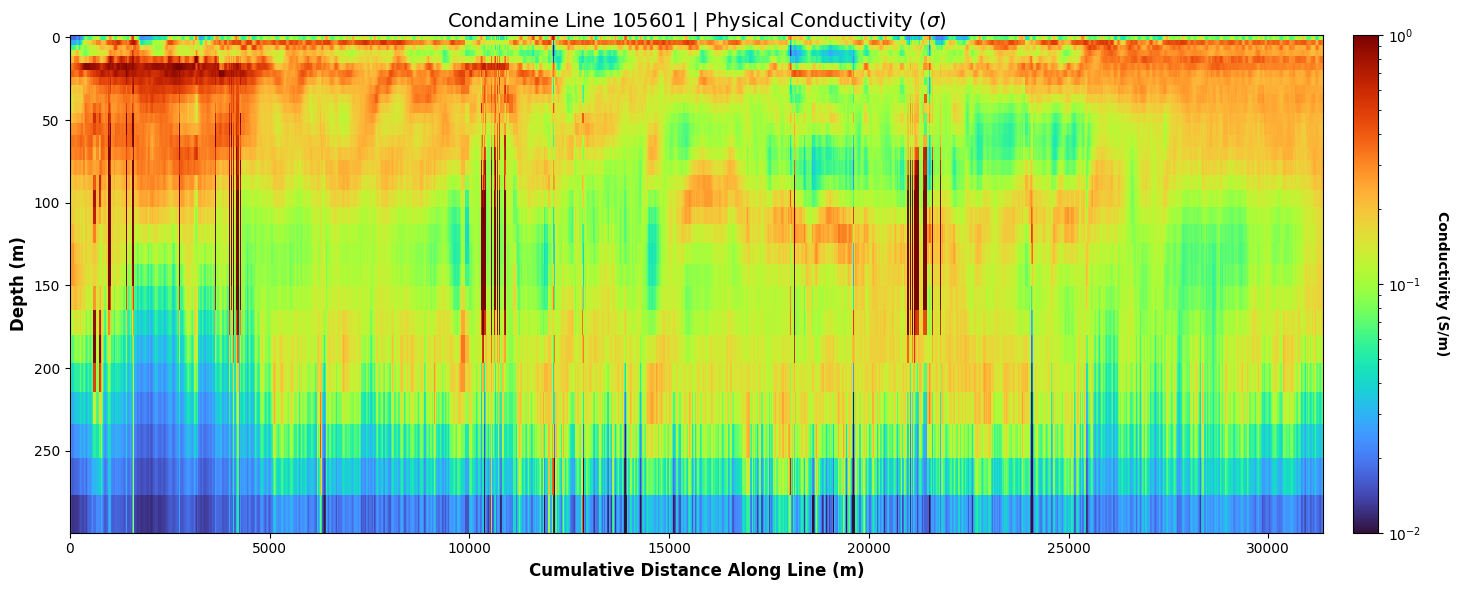

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

# Define your threshold for a "bad" fit
misfit_threshold = 1.0 

valid_times = []
distances = []
sigmas = []

current_distance = 0.0
prev_coords = None

# Sort times to ensure sequential plotting along the line
sorted_times = sorted(line_results.keys())

for time in sorted_times:
    res = line_results[time]
    
    if res.get('success', False):
        n_data = len(res['dpred'])
        chi2 = (2.0 * res['phi_d']) / n_data
        
        # Plot only the soundings that pass your QA/QC check!
        if chi2 <= misfit_threshold:
            station_info = Survey.Data.station_data.loc[(lineno, time)]
            if isinstance(station_info, pd.DataFrame): 
                station_info = station_info.iloc[0]
                
            curr_coords = np.array([float(station_info.UTMX), float(station_info.UTMY)])
            
            # Calculate cumulative distance along the line
            if prev_coords is not None:
                dist_step = np.linalg.norm(curr_coords - prev_coords)
                current_distance += dist_step
                
            prev_coords = curr_coords
            
            valid_times.append(time)
            distances.append(current_distance)
            
            # Extract the physical conductivity array from your v3 worker
            sigmas.append(res['sigma'])

# Convert to a 2D array and transpose so Depth is the y-axis
# Shape becomes (n_layers, n_valid_soundings)
sigmas_array = np.array(sigmas).T 

# Setup the Depth bounds (assuming payload_data is available in your scope)
thicknesses = payload['thicknesses']
depth_bounds = np.r_[0, np.cumsum(thicknesses)]

# --- Plotting the Section ---
fig, ax = plt.subplots(figsize=(16, 6))

# Use 'turbo' or 'jet' to make conductive clays/shales pop as 'hot' colors
# LogNorm handles the large dynamic range of conductivity (S/m)
im = ax.pcolormesh(
    distances, 
    depth_bounds, 
    sigmas_array, 
    norm=LogNorm(vmin=1e-2, vmax=1), # Adjust bounds for Condamine typical ranges
    cmap='turbo', 
    shading='auto' 
)

ax.invert_yaxis()
ax.set_ylabel('Depth (m)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cumulative Distance Along Line (m)', fontsize=12, fontweight='bold')
ax.set_title(f'Condamine Line {lineno} | Physical Conductivity ($\sigma$)', fontsize=14)

# Add Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Conductivity (S/m)', rotation=270, labelpad=20, fontweight='bold')

plt.tight_layout()
plt.show()